## AI-Based Crop Recommendation System for Smart Agriculture

### Objective
To develop a machine learning-based crop recommendation system that predicts the most suitable crop for cultivation based on soil nutrient levels (N, P, K) and environmental conditions (temperature, humidity, pH, rainfall), enabling farmers to make data-driven and efficient agricultural decisions.

### Workflow
Data Exploration → Data Preprocessing → Model Training & Comparison → Hyperparameter Tuning → Model Evaluation → Deployment (Prediction System)

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

Load & Clean Data

In [2]:
df = pd.read_csv('Crop_recommendation.csv')

print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

if df.isnull().sum().sum() > 0:
    df = df.dropna()

df.head()

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Basic EDA

In [3]:
X  = df.drop('label', axis = 1)
y = df['label']

print(df.info())
print(df.describe())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            8800 non-null   int64  
 1   P            8800 non-null   int64  
 2   K            8800 non-null   int64  
 3   temperature  8800 non-null   float64
 4   humidity     8800 non-null   float64
 5   ph           8800 non-null   float64
 6   rainfall     8800 non-null   float64
 7   label        8800 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 550.1+ KB
None
                 N            P            K  temperature     humidity  \
count  8800.000000  8800.000000  8800.000000  8800.000000  8800.000000   
mean     55.080909    51.444091    40.482727    26.774572    71.443720   
std      37.059675    27.973451    38.555468     5.322922    22.761454   
min       0.000000     4.000000     5.000000     8.825675    14.258040   
25%      25.000000    30.000000    

Correlation Heatmap

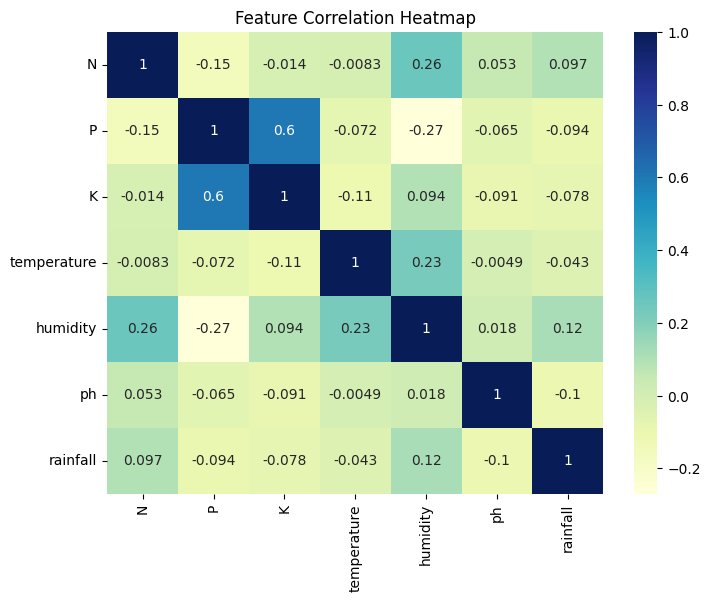

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot = True, cmap = "YlGnBu")
plt.title('Feature Correlation Heatmap')
plt.show()

Label Encoding

In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'banana': np.int64(0), 'blackgram': np.int64(1), 'chickpea': np.int64(2), 'coconut': np.int64(3), 'coffee': np.int64(4), 'cotton': np.int64(5), 'grapes': np.int64(6), 'groundnuts': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Model Comparison

In [7]:
models = {
    "RandomForest": Pipeline([
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=200))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ])
}

print("\nModel Comparison:\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=5)
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")


Model Comparison:

RandomForest: 0.9531 ± 0.0012
LogisticRegression: 0.9338 ± 0.0042
SVM: 0.9439 ± 0.0017


Hyperparameter Tuning (RandomForest with Class Balance)

In [8]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


Final Model (Pipeline Ready for Future Scaling) 

In [9]:
model = Pipeline([
    ('model', RandomForestClassifier(
        **grid.best_params_,
        random_state=42,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

Cross Validation (on Train Set)

In [10]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross-validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-validation Accuracy: 0.927840909090909
Std Dev: 0.0026037361903158084


Evaluation

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9130681818181818

Classification Report:

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        80
   blackgram       0.99      1.00      0.99        80
    chickpea       1.00      1.00      1.00        80
     coconut       1.00      1.00      1.00        80
      coffee       1.00      1.00      1.00        80
      cotton       0.98      1.00      0.99        80
      grapes       1.00      1.00      1.00        80
  groundnuts       0.13      0.12      0.13        80
        jute       0.86      1.00      0.92        80
 kidneybeans       1.00      1.00      1.00        80
      lentil       0.97      0.97      0.97        80
       maize       1.00      0.97      0.99        80
       mango       1.00      1.00      1.00        80
   mothbeans       0.17      0.17      0.17        80
    mungbean       1.00      1.00      1.00        80
   muskmelon       1.00      1.00      1.00        80
      orange       1.00    

Confusion Matrix

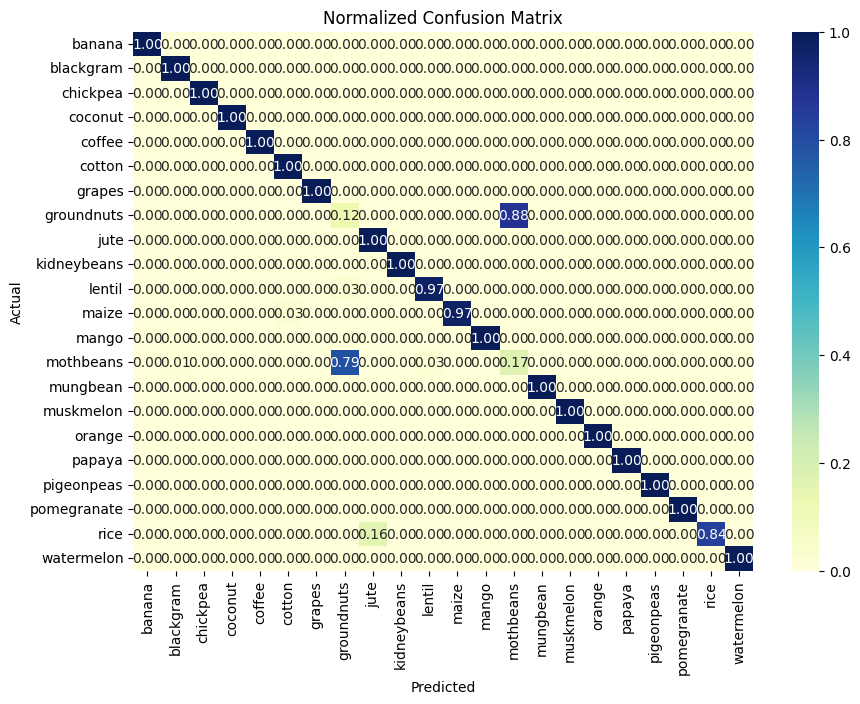

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10,7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Feature Importance

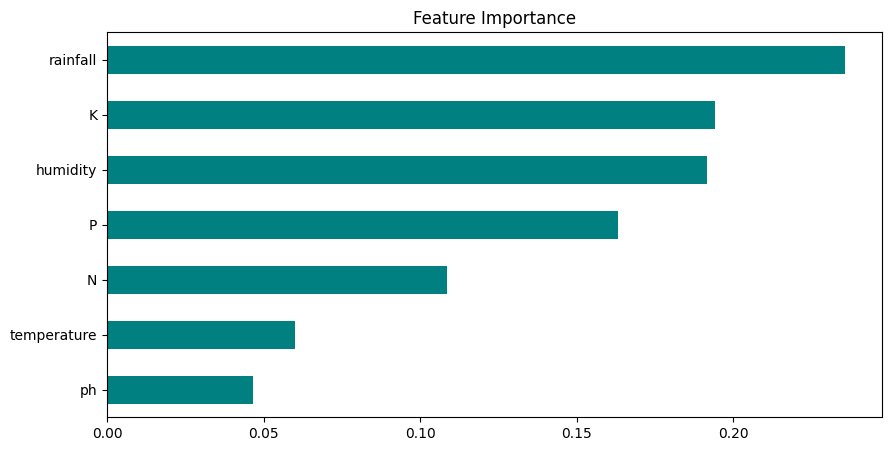

In [13]:
feat = pd.Series(
    model.named_steps['model'].feature_importances_,
    index=X.columns
)

plt.figure(figsize=(10,5))
feat.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance")
plt.show()

Input Validation

In [14]:
def validate_input(data):
    if len(data) != 7:
        raise ValueError("Input must contain exactly 7 features")

    N, P, K, temp, humidity, ph, rainfall = data

    if not (0 <= N <= 150):
        raise ValueError("Nitrogen out of range (0–150)")
    if not (0 <= P <= 150):
        raise ValueError("Phosphorus out of range (0–150)")
    if not (0 <= K <= 200):
        raise ValueError("Potassium out of range (0–200)")
    if not (0 <= temp <= 50):
        raise ValueError("Temperature out of range")
    if not (0 <= humidity <= 100):
        raise ValueError("Humidity must be 0–100")
    if not (0 <= ph <= 14):
        raise ValueError("pH must be 0–14")
    if rainfall < 0:
        raise ValueError("Rainfall cannot be negative")

Feature Order

In [15]:
feature_order = ['N','P','K','temperature','humidity','ph','rainfall']

Recommendation System (with Confidence)

In [16]:
def recommend_with_confidence(input_data, threshold=0.6):
    validate_input(input_data)

    input_df = pd.DataFrame([input_data], columns=feature_order)

    probs = model.predict_proba(input_df)[0]

    top_idx = np.argsort(probs)[::-1][:3]
    top_k = [(le.inverse_transform([i])[0], probs[i]) for i in top_idx]

    best_crop, best_prob = top_k[0]

    result = {
        "best_crop": best_crop,
        "confidence": round(best_prob, 3),
        "top_suggestions": [(crop, round(prob, 2)) for crop, prob in top_k],
        "status": "Low confidence" if best_prob < threshold else "High confidence"
    }

    return result

Multiple Sample Testing

In [17]:
samples = [
    [40, 50, 50, 25.5, 70.0, 6.8, 150.0],
    [20, 60, 30, 28.0, 80.0, 5.8, 100.0],
    [120, 40, 20, 22.0, 60.0, 7.0, 300.0]
]

for i, sample in enumerate(samples, 1):
    print(f"\n🌾 Sample {i}")
    
    result = recommend_with_confidence(sample)
    
    print(f"Best Crop: {result['best_crop']}")
    print(f"Confidence: {result['confidence']}")
    print(f"Status: {result['status']}")
    print("Top Suggestions:")
    
    for crop, prob in result['top_suggestions']:
        print(f"  - {crop}: {prob}")


🌾 Sample 1
Best Crop: papaya
Confidence: 0.246
Status: Low confidence
Top Suggestions:
  - papaya: 0.25
  - pigeonpeas: 0.24
  - jute: 0.22

🌾 Sample 2
Best Crop: pigeonpeas
Confidence: 0.173
Status: Low confidence
Top Suggestions:
  - pigeonpeas: 0.17
  - mungbean: 0.15
  - pomegranate: 0.1

🌾 Sample 3
Best Crop: coffee
Confidence: 0.548
Status: Low confidence
Top Suggestions:
  - coffee: 0.55
  - maize: 0.24
  - rice: 0.11


Save Model

In [18]:
joblib.dump({"model": model, "encoder": le}, "crop_system.pkl")

['crop_system.pkl']